In [2]:
getwd()
setwd("/liulab/galib/dlbcl_manuscript/")
library(rBCS)
library(tidyverse)
library(Seurat)
library(harmony)
library(viridis)
library(RColorBrewer)
library(Polychrome)
PurpleAndYellow()
library(ComplexHeatmap)
library(devtools)
library(presto)
library(dplyr)
library(ggplot2)
library(ggpubr)
library(readxl)
library(DESeq2)
set.seed(123)
source("./scripts/scplot.R")

[1] "/liulab/galib/dlbcl_manuscript/scripts/Revision"

Warning message:
“package ‘rBCS’ was built under R version 4.1.3”
Warning message:
“package ‘tidyverse’ was built under R version 4.1.3”
── Attaching packages ─────────────────────────────────────── tidyverse 1.3.1 ──

✔ ggplot2 3.3.6      ✔ purrr   0.3.4 
✔ tibble  3.1.8      ✔ dplyr   1.0.10
✔ tidyr   1.2.0      ✔ stringr 1.4.1 
✔ readr   2.1.2      ✔ forcats 0.5.1 

Warning message:
“package ‘tidyr’ was built under R version 4.1.2”
Warning message:
“package ‘readr’ was built under R version 4.1.2”
Warning message:
“package ‘forcats’ was built under R version 4.1.3”
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()

Attaching SeuratObject

Attaching sp

Warning message:
“package ‘harmony’ was built under R version 4.1.3”
Loading required package: Rcpp

Warning message:
“package ‘Rcpp’ was built under R version 4.1.2”
Loading required package: viridisLite

Warning message:
“pack

[1] "#FF00FF" "#F400F4" "#EA00EA" "#DF00DF" "#D500D5" "#CA00CA" "#BF00BF"
 [8] "#B500B5" "#AA00AA" "#9F009F" "#950095" "#8A008A" "#800080" "#750075"
[15] "#6A006A" "#600060" "#550055" "#4A004A" "#400040" "#350035" "#2B002B"
[22] "#200020" "#150015" "#0B000B" "#000000" "#000000" "#0B0B00" "#151500"
[29] "#202000" "#2B2B00" "#353500" "#404000" "#4A4A00" "#555500" "#606000"
[36] "#6A6A00" "#757500" "#808000" "#8A8A00" "#959500" "#9F9F00" "#AAAA00"
[43] "#B5B500" "#BFBF00" "#CACA00" "#D4D400" "#DFDF00" "#EAEA00" "#F4F400"
[50] "#FFFF00"

Warning message:
“package ‘ComplexHeatmap’ was built under R version 4.1.3”
Loading required package: grid

ComplexHeatmap version 2.10.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite:
Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
  genomic data. Bioinformatics 2016.

The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


Loading required package: usethis

Warning message:
“package ‘presto’ was built under R version 4.1.3”
Loading required package: data.table


Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last


The

In [11]:
run_de_pseudobulk_deseq2 <- function(obj, outdir, prefix) {

    set.seed(123)

    raw_counts <- AggregateExpression(obj, group.by = "orig.ident", slot = "counts")
    count_matrix <- round(as.matrix(raw_counts$RNA))
    
    
    keep_genes <- rowSums(count_matrix >= 3) >= 3
    count_matrix <- count_matrix[keep_genes, ]

    coldata <- obj@meta.data %>%
        distinct(orig.ident, genotype) %>%
        as.data.frame(row.names = NULL)
    rownames(coldata) <- coldata$orig.ident
    coldata$orig.ident <- NULL
    coldata <- coldata[colnames(count_matrix), , drop = FALSE]
    coldata$genotype <- factor(coldata$genotype, levels = c("Bcl6tg/+", "CD70-/-;Bcl6tg/+"))

    dds <- DESeqDataSetFromMatrix(countData = count_matrix,
                                  colData = coldata,
                                  design = ~ genotype)
    dds <- DESeq(dds)
    res <- results(dds, contrast = c("genotype", "CD70-/-;Bcl6tg/+", "Bcl6tg/+"))

    markers <- as.data.frame(res) %>%
        rownames_to_column("feature") %>%
        dplyr::rename(logFC = log2FoldChange, p = pvalue) %>%
        dplyr::mutate(padj_BH = p.adjust(p, method = "BH"))  %>% 
        dplyr::select(feature, logFC, p, padj_BH) %>%
        arrange(padj_BH)


    write_tsv(markers, paste0(outdir, prefix, "_all_markers.tsv"))

    # Volcano plot
    markers$neg_log10_padj <- -log10(markers$padj_BH)
    markers$sig <- case_when(
        markers$padj_BH <= 0.05 & markers$logFC >= 1.0  ~ "Up",
        markers$padj_BH <= 0.05 & markers$logFC <= -1.0 ~ "Down",
        TRUE ~ "NS"
    )

    top_genes <- markers %>%
        filter(sig != "NS") %>%
        arrange(padj_BH) %>%
        slice_head(n = 20)

    p_volcano <- ggplot(markers, aes(x = logFC, y = neg_log10_padj, color = sig)) +
        geom_point(alpha = 0.5, size = 1) +
        scale_color_manual(values = c("Up" = "#E64B35", "Down" = "#4DBBD5", "NS" = "grey70")) +
        geom_vline(xintercept = c(-1.0, 1.0), linetype = "dashed", color = "black") +
        geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "black") +
        ggrepel::geom_text_repel(
            data = top_genes,
            aes(label = feature),
            size = 3, max.overlaps = 20, color = "black"
        ) +
        labs(
            title = paste0(prefix, ":\nVolcano plot padj <= 0.05 abs(logFC) >= 1.0"),
            x = "log2 Fold Change",
            y = "-log10(adjusted p-value)",
            color = NULL
        ) +
        theme_classic(base_size = 14)

    ggsave(paste0(outdir, prefix, "_volcano_plot.pdf"), p_volcano, width = 7, height = 5)

    # Histograms
    p_padj <- ggplot(markers, aes(x = padj_BH)) +
        geom_histogram(bins = 30, fill = "#4DBBD5", color = "black") +
        geom_vline(xintercept = 0.05, linetype = "dashed", color = "red") +
        labs(
            title = paste0(prefix, ":\nAdjusted p-value distribution"),
            x = "Adjusted p-value",
            y = "Number of genes"
        ) + theme_classic(base_size = 14)

    p_logfc <- ggplot(markers, aes(x = logFC)) +
        geom_histogram(bins = 30, fill = "#E64B35", color = "black") +
        geom_vline(xintercept = c(-1.0, 1.0), linetype = "dashed", color = "blue") +
        labs(
            title = paste0(prefix, ":\nlog2 Fold Change distribution"),
            x = "log2 Fold Change",
            y = "Number of genes"
        ) + theme_classic(base_size = 14)

    ggsave(paste0(outdir, prefix, "_padj_histogram.pdf"), p_padj, width = 5, height = 4)
    ggsave(paste0(outdir, prefix, "_logFC_histogram.pdf"), p_logfc, width = 5, height = 4)

    # Significant markers
    markers_sig <- markers %>% filter(padj_BH <= 0.05, abs(logFC) >= 1.0) %>% arrange(padj_BH)
    write_tsv(markers_sig, paste0(outdir, prefix, "_significant_markers_padj_0.05_abslogFC_1.0.tsv"))

    up_in_double <- markers_sig %>%
        filter(logFC > 0) %>%
        arrange(padj_BH) %>%
        slice_head(n = 10)

    down_in_double <- markers_sig %>%
        filter(logFC < 0) %>%
        arrange(padj_BH) %>%
        slice_head(n = 10)

    genelist <- c(up_in_double$feature, down_in_double$feature) %>% unique()

    if (length(genelist) == 0) {
        message("No significant DE genes for ", prefix)
    } else {
        write_tsv(up_in_double, paste0(outdir, prefix, "_top10_up_regulated_in_double.tsv"))
        write_tsv(down_in_double, paste0(outdir, prefix, "_top10_down_regulated_in_double.tsv"))

        p <- DotPlot(object = obj, features = genelist, group.by = "genotype", scale = TRUE) +
            theme(axis.text.x = element_text(angle = 90, hjust = 1)) +
            labs(title = prefix, y = "genotype")
        ggsave(paste0(outdir, prefix, "_top10_up_and_down_regulated_genes_in_double.pdf"), p, width = 7, height = 4)

        p <- VlnPlot(obj, features = genelist, group.by = "genotype", ncol = 10, pt.size = 0.2)
        ggsave(paste0(outdir, prefix, "_top10_up_and_down_regulated_genes_in_double_vlnplot.pdf"), p, width = 12, height = 5)

        p <- VlnPlot(obj, features = genelist, group.by = "orig.ident", split.by = "genotype",
                      pt.size = 0.2, stack = TRUE, sort = TRUE, flip = TRUE)
        ggsave(paste0(outdir, prefix, "_top10_up_and_down_regulated_genes_in_double_vlnplot_by_sample.pdf"), p, width = 14, height = 8)
    }
}

In [4]:
# Diff analysis and GSEA (and volcano plots) of CD21low/Cd23low B cells 
# (C4, 5, 7, 8, 15, 18, 19, 21, 22) in Bcl6 vs double mice at: 
# 6 mos, 14 mos, 18 mos, sick, 14+18+sick, all time points.

In [5]:
B_cell<- readRDS("./data/objects/B_cell_final.rds")

In [6]:
B_cell$seurat_clusters  %>% table()
B_cell$age  %>% table()
B_cell$genotype  %>% table()

.
    0     1     2     3     4     5     6     7     8     9    10    11    12 
33780 15208 11335 10056  9745  9227  9141  8184  8004  7844  6013  5794  5992 
   13    14    15    16    17    18    19    20    21    22    23    24    25 
 4565  3819  3244  2914  2816  2646  2463  2362  2141  2126  2054  1933  1656 
   27 
 1521 

.
14mos 18mos  6mos  sick 
44738 54964 59820 17061 

.
        Bcl6tg/+          CD70-/- CD70-/-;Bcl6tg/+               WT 
           37154            46791            48414            44224 

In [12]:
# Downsample malignant B cell in Bck6 and double mice,all time points

sub_clusters<- c(4, 5, 7, 8, 15, 18, 19, 21, 22)

prefix = 'b_cell_cd21_cd23_low_de_all_timepoints'

cd21_cd23_low_cells<- 
    B_cell@meta.data  %>% 
    filter(seurat_clusters %in% sub_clusters, 
    genotype %in% c("Bcl6tg/+", "CD70-/-;Bcl6tg/+"))  %>% rownames()

B_cell_cd21_cd23_low<- subset(B_cell, cells = cd21_cd23_low_cells)


# run_de(B_cell_cd21_cd23_low, outdir = './data/revision/', prefix = prefix)
# run_de_pseudobulk(B_cell_cd21_cd23_low, outdir = './data/revision/pseudobulk_de/', prefix = prefix) 
B_cell_cd21_cd23_low@meta.data  %>% distinct(genotype, orig.ident)  %>% dplyr::count(genotype)
run_de_pseudobulk_deseq2(B_cell_cd21_cd23_low, outdir = './data/revision/pseudobulk_de/deseq2/', prefix = prefix) 

genotype,n
<chr>,<int>
Bcl6tg/+,25
CD70-/-;Bcl6tg/+,28


converting counts to integer mode

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R.

### check MHCII expression

In [18]:
sub_clusters<- c(4, 5, 7, 8, 15, 18, 19, 21, 22)

prefix = 'b_cell_cd21_cd23_low_de_all_timepoints'

cd21_cd23_low_cells<- 
    B_cell@meta.data  %>% 
    filter(seurat_clusters %in% sub_clusters, 
    genotype %in% c("Bcl6tg/+", "CD70-/-;Bcl6tg/+"))  %>% rownames()

B_cell_cd21_cd23_low<- subset(B_cell, cells = cd21_cd23_low_cells)

meta<- B_cell_cd21_cd23_low@meta.data  %>% distinct(orig.ident, age, genotype)
rownames(meta)<- meta$orig.ident

counts <- AggregateExpression(B_cell_cd21_cd23_low, group.by = "orig.ident", slot = "counts")
counts = counts$RNA
log2cpm<- NormalizeData(counts)  %>% as.matrix()

In [69]:
B_cell_cd21_cd23_low@meta.data  %>% dplyr::count(genotype, age)  %>% arrange(age)

genotype,age,n
<chr>,<chr>,<int>
Bcl6tg/+,14mos,1095
CD70-/-;Bcl6tg/+,14mos,5162
Bcl6tg/+,18mos,5297
CD70-/-;Bcl6tg/+,18mos,8837
Bcl6tg/+,6mos,1097
CD70-/-;Bcl6tg/+,6mos,2988
Bcl6tg/+,sick,4364
CD70-/-;Bcl6tg/+,sick,5232


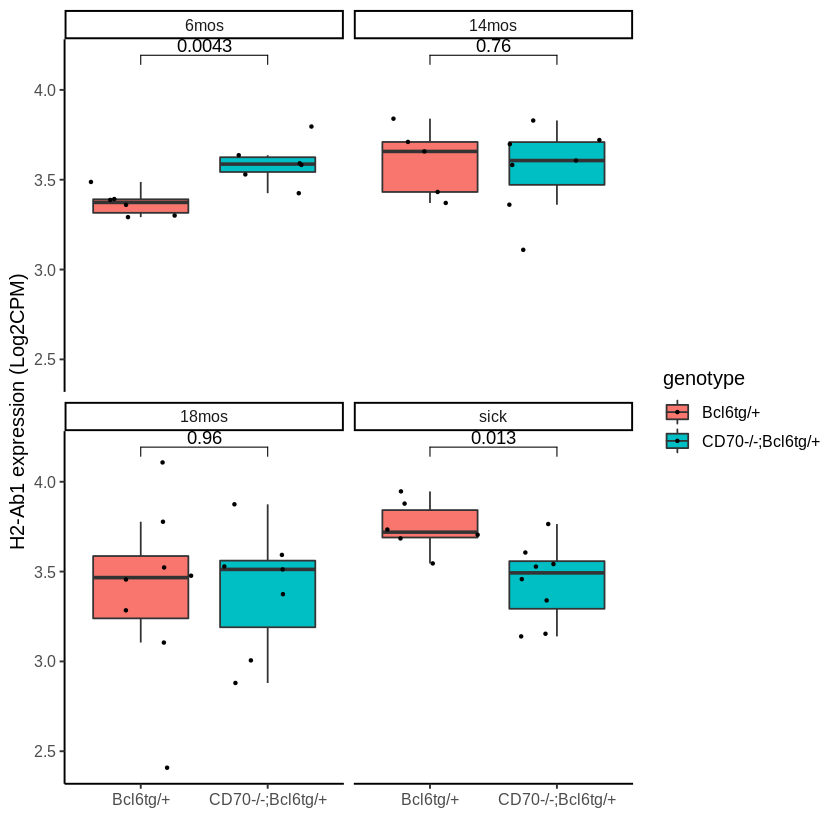

In [65]:
geneid = "H2-Ab1"
expr = log2cpm[geneid, ]
df<- cbind(meta[names(expr), ], expr)
df$age = factor(df$age, levels = c("6mos", "14mos", "18mos", "sick"))

df  %>% 
    ggplot(aes(x = genotype, y = expr, fill = genotype)) +
    geom_boxplot(outlier.shape = NA) +
    geom_jitter(size = 0.6) +
    theme_classic(base_size = 12) +
    facet_wrap(facets = "age") +
    stat_compare_means(method = "wilcox.test", 
                       label = "p.format",
                       comparisons = list(c("Bcl6tg/+", "CD70-/-;Bcl6tg/+"))) +
    labs(x = "", y = paste0(geneid, " expression (Log2CPM)"))

ggsave(paste0("./data/revision/pseudobulk_de/260318_",geneid, "_expression_by_genotype_by_age.pdf"), width = 7, height = 6)

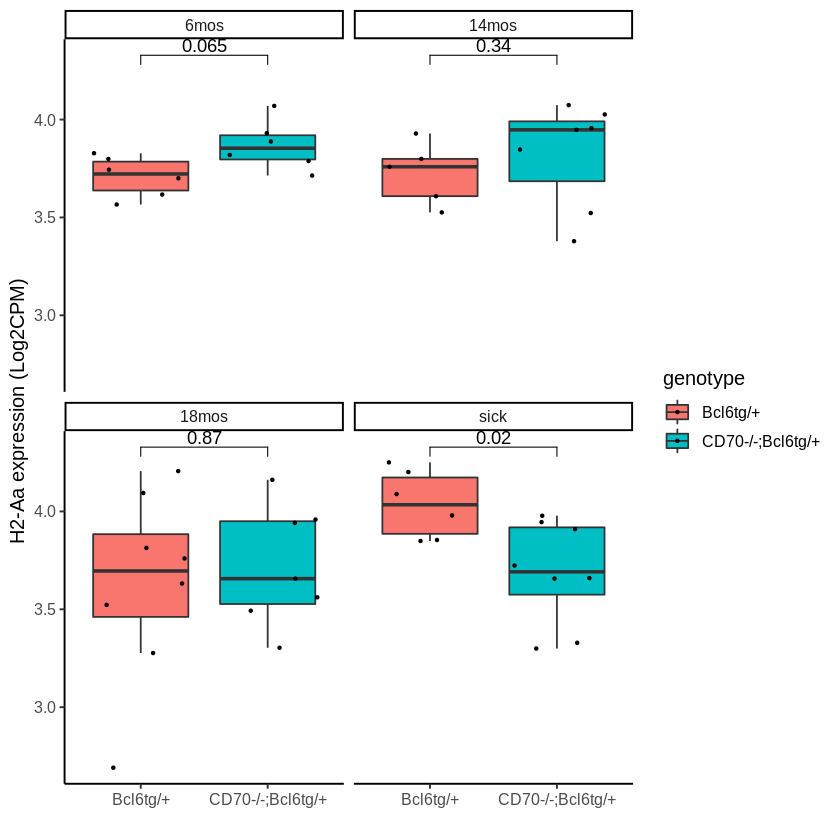

In [66]:
geneid = "H2-Aa"
expr = log2cpm[geneid, ]
df<- cbind(meta[names(expr), ], expr)
df$age = factor(df$age, levels = c("6mos", "14mos", "18mos", "sick"))

df  %>% 
    ggplot(aes(x = genotype, y = expr, fill = genotype)) +
    geom_boxplot(outlier.shape = NA) +
    geom_jitter(size = 0.6) +
    theme_classic(base_size = 12) +
    facet_wrap(facets = "age") +
    stat_compare_means(method = "wilcox.test", 
                       label = "p.format",
                       comparisons = list(c("Bcl6tg/+", "CD70-/-;Bcl6tg/+"))) +
    labs(x = "", y = paste0(geneid, " expression (Log2CPM)"))

ggsave(paste0("./data/revision/pseudobulk_de/260318_",geneid, "_expression_by_genotype_by_age.pdf"), width = 7, height = 6)

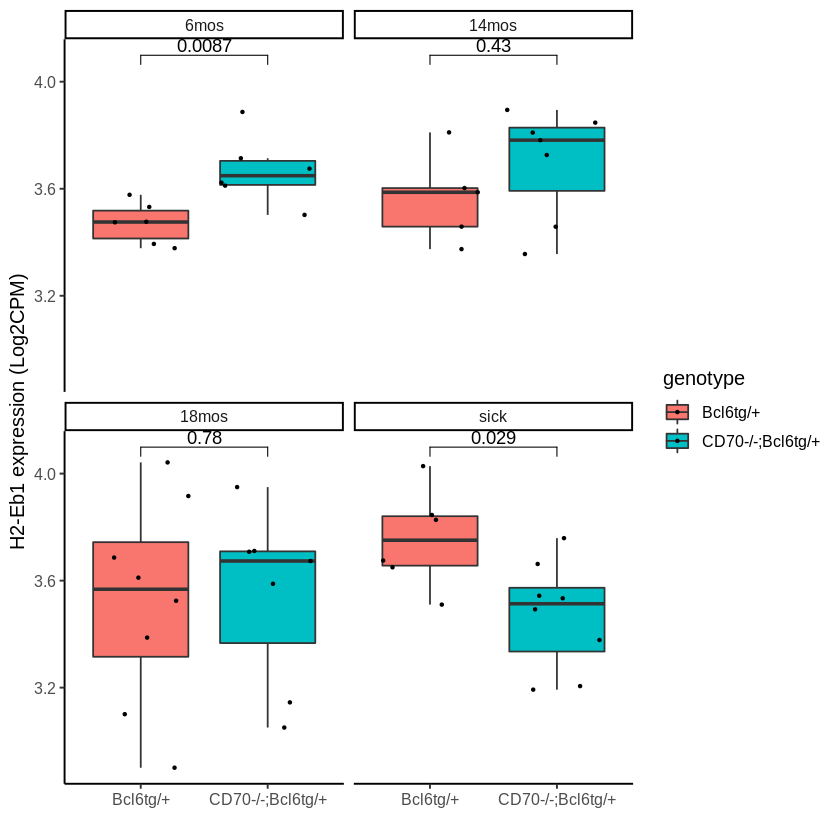

In [67]:
geneid = "H2-Eb1"
expr = log2cpm[geneid, ]
df<- cbind(meta[names(expr), ], expr)
df$age = factor(df$age, levels = c("6mos", "14mos", "18mos", "sick"))

df  %>% 
    ggplot(aes(x = genotype, y = expr, fill = genotype)) +
    geom_boxplot(outlier.shape = NA) +
    geom_jitter(size = 0.6) +
    theme_classic(base_size = 12) +
    facet_wrap(facets = "age") +
    stat_compare_means(method = "wilcox.test", 
                       label = "p.format",
                       comparisons = list(c("Bcl6tg/+", "CD70-/-;Bcl6tg/+"))) +
    labs(x = "", y = paste0(geneid, " expression (Log2CPM)"))

ggsave(paste0("./data/revision/pseudobulk_de/260318_",geneid, "_expression_by_genotype_by_age.pdf"), width = 7, height = 6)

In [ ]:
df  %>% 
    ggplot(aes(x = genotype, y = expr, fill = genotype)) +
    geom_boxplot(outlier.shape = NA) +
    geom_jitter(size = 0.6) +
    theme_classic(base_size = 14) +
    facet_wrap(facets = "age") +
    stat_compare_means(method = "wilcox.test", 
                       label = "p.format",
                       comparisons = list(c("Bcl6tg/+", "CD70-/-;Bcl6tg/+"))) +
    labs(x = "", y = "H2-Ab1 expression (Log2CPM)")

In [13]:
# Downsample malignant B cell in Bck6 and double mice, 6mos

prefix = 'b_cell_cd21_cd23_low_de_6mos'

cd21_cd23_low_cells<- 
    B_cell@meta.data  %>% 
    filter(seurat_clusters %in% sub_clusters, 
    genotype %in% c("Bcl6tg/+", "CD70-/-;Bcl6tg/+"),
    age %in% c("6mos"))  %>% rownames()

length(cd21_cd23_low_cells)

B_cell_cd21_cd23_low<- subset(B_cell, cells = cd21_cd23_low_cells)

# run_de(B_cell_cd21_cd23_low, outdir = './data/revision/', prefix = prefix)
# run_de_pseudobulk(B_cell_cd21_cd23_low, outdir = './data/revision/pseudobulk_de/', prefix = prefix) 
B_cell_cd21_cd23_low@meta.data  %>% distinct(genotype, orig.ident)  %>% dplyr::count(genotype)
run_de_pseudobulk_deseq2(B_cell_cd21_cd23_low, outdir = './data/revision/pseudobulk_de/deseq2/', prefix = prefix) 

[1] 4085

genotype,n
<chr>,<int>
Bcl6tg/+,6
CD70-/-;Bcl6tg/+,6


converting counts to integer mode

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R.

In [14]:
# Downsample malignant B cell in Bck6 and double mice, 14mos

prefix = 'b_cell_cd21_cd23_low_de_14mos'

cd21_cd23_low_cells<- 
    B_cell@meta.data  %>% 
    filter(seurat_clusters %in% sub_clusters, 
    genotype %in% c("Bcl6tg/+", "CD70-/-;Bcl6tg/+"),
    age %in% c("14mos"))  %>% rownames()

length(cd21_cd23_low_cells)

B_cell_cd21_cd23_low<- subset(B_cell, cells = cd21_cd23_low_cells)

# run_de(B_cell_cd21_cd23_low, outdir = './data/revision/', prefix = prefix)
# run_de_pseudobulk(B_cell_cd21_cd23_low, outdir = './data/revision/pseudobulk_de/', prefix = prefix) 

B_cell_cd21_cd23_low@meta.data  %>% distinct(genotype, orig.ident)  %>% dplyr::count(genotype)
run_de_pseudobulk_deseq2(B_cell_cd21_cd23_low, outdir = './data/revision/pseudobulk_de/deseq2/', prefix = prefix) 

[1] 6257

genotype,n
<chr>,<int>
Bcl6tg/+,5
CD70-/-;Bcl6tg/+,7


converting counts to integer mode

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R.

In [15]:
# Downsample malignant B cell in Bck6 and double mice, 18mos

prefix = 'b_cell_cd21_cd23_low_de_18mos'

cd21_cd23_low_cells<- 
    B_cell@meta.data  %>% 
    filter(seurat_clusters %in% sub_clusters, 
    genotype %in% c("Bcl6tg/+", "CD70-/-;Bcl6tg/+"),
    age %in% c("18mos"))  %>% rownames()

length(cd21_cd23_low_cells)

B_cell_cd21_cd23_low<- subset(B_cell, cells = cd21_cd23_low_cells)


# run_de(B_cell_cd21_cd23_low, outdir = './data/revision/', prefix = prefix)
# run_de_pseudobulk(B_cell_cd21_cd23_low, outdir = './data/revision/pseudobulk_de/', prefix = prefix) 
B_cell_cd21_cd23_low@meta.data  %>% distinct(genotype, orig.ident)  %>% dplyr::count(genotype)
run_de_pseudobulk_deseq2(B_cell_cd21_cd23_low, outdir = './data/revision/pseudobulk_de/deseq2/', prefix = prefix) 

[1] 14134

genotype,n
<chr>,<int>
Bcl6tg/+,8
CD70-/-;Bcl6tg/+,7


converting counts to integer mode

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R.

In [16]:
# Downsample malignant B cell in Bck6 and double mice, sick

prefix = 'b_cell_cd21_cd23_low_de_sick'

cd21_cd23_low_cells<- 
    B_cell@meta.data  %>% 
    filter(seurat_clusters %in% sub_clusters, 
    genotype %in% c("Bcl6tg/+", "CD70-/-;Bcl6tg/+"),
    age %in% c("sick"))  %>% rownames()

length(cd21_cd23_low_cells)

B_cell_cd21_cd23_low<- subset(B_cell, cells = cd21_cd23_low_cells)

# run_de(B_cell_cd21_cd23_low, outdir = './data/revision/', prefix = prefix)
# run_de_pseudobulk(B_cell_cd21_cd23_low, outdir = './data/revision/pseudobulk_de/', prefix = prefix) 
B_cell_cd21_cd23_low@meta.data  %>% distinct(genotype, orig.ident)  %>% dplyr::count(genotype)
run_de_pseudobulk_deseq2(B_cell_cd21_cd23_low, outdir = './data/revision/pseudobulk_de/deseq2/', prefix = prefix) 

[1] 9596

genotype,n
<chr>,<int>
Bcl6tg/+,6
CD70-/-;Bcl6tg/+,8


converting counts to integer mode

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R.

In [ ]:
# Downsample malignant B cell in Bck6 and double mice, 14mos + 18mos + sick

prefix = 'b_cell_cd21_cd23_low_de_14_18_sick'

cd21_cd23_low_cells<- 
    B_cell@meta.data  %>% 
    filter(seurat_clusters %in% sub_clusters, 
    genotype %in% c("Bcl6tg/+", "CD70-/-;Bcl6tg/+"),
    age %in% c("14mos", "18mos", "sick"))  %>% rownames()

length(cd21_cd23_low_cells)

B_cell_cd21_cd23_low<- subset(B_cell, cells = cd21_cd23_low_cells)

# run_de(B_cell_cd21_cd23_low, outdir = './data/revision/', prefix = prefix)
# run_de_pseudobulk(B_cell_cd21_cd23_low, outdir = './data/revision/pseudobulk_de/', prefix = prefix)

B_cell_cd21_cd23_low@meta.data  %>% distinct(genotype, orig.ident)  %>% dplyr::count(genotype)
run_de_pseudobulk_deseq2(B_cell_cd21_cd23_low, outdir = './data/revision/pseudobulk_de/deseq2/', prefix = prefix) 

[1] 29987

genotype,n
<chr>,<int>
Bcl6tg/+,19
CD70-/-;Bcl6tg/+,22


converting counts to integer mode

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R.

### dominant clonotype vs b cell 

In [188]:
dominant_cdr<- read_excel('./data/Barcode_clonotype_dominant.xlsx', sheet = "Sheet1")
B_cell$dominant = ifelse(Cells(B_cell) %in% dominant_cdr$barcode, "dominant", "non-dominant")

In [13]:
# Downsample malignant B cell in Bck6 and double mice, 18mos
prefix = 'b_cell_cd21_cd23_low_de_18mos'

cd21_cd23_low_cells<- 
    B_cell@meta.data  %>% 
    filter(seurat_clusters %in% sub_clusters, 
    genotype %in% c("Bcl6tg/+", "CD70-/-;Bcl6tg/+"),
    age %in% c("18mos"))  %>% rownames()

B_cell_cd21_cd23_low<- subset(B_cell, cells = cd21_cd23_low_cells)

B_cell_cd21_cd23_low$group <- paste0(B_cell_cd21_cd23_low$genotype, "\n", B_cell_cd21_cd23_low$dominant)

comparisons <- list(
    c("Bcl6tg/+\ndominant", "Bcl6tg/+\nnon-dominant"),
    c("CD70-/-;Bcl6tg/+\ndominant", "CD70-/-;Bcl6tg/+\nnon-dominant")
)

p <- VlnPlot(B_cell_cd21_cd23_low, features = "Aicda", group.by = "group", pt.size = 0.2, slot = "data") +
#     stat_compare_means(comparisons = comparisons, method = "wilcox.test", label = "p.signif") +
    theme_classic(base_size = 14) +
    theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5)) +
    labs(title = "Aicda expression in cd21_cd23 low at 18mos")
ggsave("./data/revision/pseudobulk_de/deseq2/aicda_expression_18mos_by_genotype_cdr3_clones.pdf", p, width = 5, height = 4)

plot_data <- FetchData(B_cell_cd21_cd23_low, vars = c("Aicda", "orig.ident", "genotype"))

p <- ggplot(plot_data, aes(x = orig.ident, y = Aicda, fill = genotype)) +
    geom_violin(scale = "width", trim = TRUE) +
    geom_jitter(size = 0.2, alpha = 0.3, width = 0.2) +
    facet_wrap(~ genotype, scales = "free_x") +
    theme_classic(base_size = 14) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1),
          legend.position = "none") +
    labs(title = "Aicda expression in cd21_cd23 low at 18mos",
         x = NULL, y = "Expression")

ggsave("./data/revision/pseudobulk_de/deseq2/aicda_expression_18mos_mice.pdf", p, width = 12, height = 5)

plot_data <- FetchData(B_cell_cd21_cd23_low, vars = c("Aicda", "orig.ident", "genotype", "dominant"))

p <- ggplot(plot_data, aes(x = orig.ident, y = Aicda, fill = genotype)) +
    geom_violin(scale = "width", trim = TRUE) +
    geom_jitter(size = 0.2, alpha = 0.3, width = 0.2) +
    facet_wrap(dominant~ genotype, scales = "free_x") +
    theme_classic(base_size = 14) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1),
          legend.position = "none") +
    labs(title = "Aicda expression in cd21_cd23 low at 18mos",
         x = NULL, y = "Expression")

ggsave("./data/revision/pseudobulk_de/deseq2/aicda_expression_18mos_by_mice_cdr3_clones.pdf", p, width = 8, height = 8)

In [14]:
prefix = 'b_cell_cd21_cd23_low_de_14mos'

cd21_cd23_low_cells<- 
    B_cell@meta.data  %>% 
    filter(seurat_clusters %in% sub_clusters, 
    genotype %in% c("Bcl6tg/+", "CD70-/-;Bcl6tg/+"),
    age %in% c("14mos"))  %>% rownames()

B_cell_cd21_cd23_low<- subset(B_cell, cells = cd21_cd23_low_cells)

B_cell_cd21_cd23_low$group <- paste0(B_cell_cd21_cd23_low$genotype, "\n", B_cell_cd21_cd23_low$dominant)

comparisons <- list(
    c("Bcl6tg/+\ndominant", "Bcl6tg/+\nnon-dominant"),
    c("CD70-/-;Bcl6tg/+\ndominant", "CD70-/-;Bcl6tg/+\nnon-dominant")
)

p <- VlnPlot(B_cell_cd21_cd23_low, features = "Aicda", group.by = "group", pt.size = 0.2, slot = "data") +
#     stat_compare_means(comparisons = comparisons, method = "wilcox.test", label = "p.signif") +
    theme_classic(base_size = 14) +
    theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5)) +
    labs(title = "Aicda expression in cd21_cd23 low at 14mos")
ggsave("./data/revision/pseudobulk_de/deseq2/aicda_expression_14mos_by_genotype_cdr3_clones.pdf", p, width = 5, height = 4)

plot_data <- FetchData(B_cell_cd21_cd23_low, vars = c("Aicda", "orig.ident", "genotype"))

p <- ggplot(plot_data, aes(x = orig.ident, y = Aicda, fill = genotype)) +
    geom_violin(scale = "width", trim = TRUE) +
    geom_jitter(size = 0.2, alpha = 0.3, width = 0.2) +
    facet_wrap(~ genotype, scales = "free_x") +
    theme_classic(base_size = 14) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1),
          legend.position = "none") +
    labs(title = "Aicda expression in cd21_cd23 low at 14mos",
         x = NULL, y = "Expression")

ggsave("./data/revision/pseudobulk_de/deseq2/aicda_expression_14mos_mice.pdf", p, width = 12, height = 5)

plot_data <- FetchData(B_cell_cd21_cd23_low, vars = c("Aicda", "orig.ident", "genotype", "dominant"))

p <- ggplot(plot_data, aes(x = orig.ident, y = Aicda, fill = genotype)) +
    geom_violin(scale = "width", trim = TRUE) +
    geom_jitter(size = 0.2, alpha = 0.3, width = 0.2) +
    facet_wrap(dominant~ genotype, scales = "free_x") +
    theme_classic(base_size = 14) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1),
          legend.position = "none") +
    labs(title = "Aicda expression in cd21_cd23 low at 14mos",
         x = NULL, y = "Expression")

ggsave("./data/revision/pseudobulk_de/deseq2/aicda_expression_14mos_by_mice_cdr3_clones.pdf", p, width = 8, height = 8)

### SHM information: all timpoints

In [29]:
# cd21_cd23_low_cells<- 
#     B_cell@meta.data  %>% 
#     filter(seurat_clusters %in% sub_clusters, 
#     genotype %in% c("Bcl6tg/+", "CD70-/-;Bcl6tg/+"))  %>% rownames()

# B_cell_cd21_cd23_low<- subset(B_cell, cells = cd21_cd23_low_cells)

In [189]:
B_cell

An object of class Seurat 
32285 features across 176583 samples within 1 assay 
Active assay: RNA (32285 features, 2000 variable features)
 3 dimensional reductions calculated: pca, harmony, umap

In [190]:
Aicda_expr <- FetchData(B_cell, vars = "Aicda", slot = "data")
write.table(x = Aicda_expr,  '../dlbcl_manuscript_v0/data/Aicda_log2tpm.tsv', quote = FALSE, sep = "\t", 
            col.names = T, row.names = T)

In [191]:
# B_cell_shm_analysis<- read_tsv('../dlbcl_manuscript_v0/data/shm_completevdj_igh.tsv')
# B_cell_shm_analysis$barcode <- sub("_\\d+$", "", B_cell_shm_analysis$sequence_id)
B_cell_shm_analysis<- read.table('../dlbcl_manuscript_v0/data/trust4_with_meta_260325.tsv', 
                                 row.names = 1, header = T, sep = "\t", fill = T)

shm<- B_cell_shm_analysis  %>% select(age, genotype, seurat_clusters, SHM, FR_SHM, CDR_SHM, FR_synSHM, CDR_synSHM, CDR_Lossos_p, FR_Lossos_p)

Warning message in scan(file = file, what = what, sep = sep, quote = quote, dec = dec, :
“embedded nul(s) found in input”


In [199]:
shared_cells<- intersect(rownames(Aicda_expr), rownames(shm))
length(shared_cells)

[1] 95277

In [202]:
df<- cbind(data.frame(aicda = Aicda_expr[shared_cells, ]), 
           shm[shared_cells, ],
          data.frame(sampleid = B_cell@meta.data[shared_cells, "orig.ident"]))  %>% 
    filter(!is.na(SHM)) 

In [208]:
df<- df  %>% mutate(age = factor(age, levels = c("6mos", "14mos", "18mos", "sick")),
                    genotype = factor(genotype, levels = c("WT", "CD70-/-", "Bcl6tg/+", "CD70-/-;Bcl6tg/+")))

In [209]:
nonzero_df<- df[df$aicda != 0,  ]

Saving 6.67 x 6.67 in image



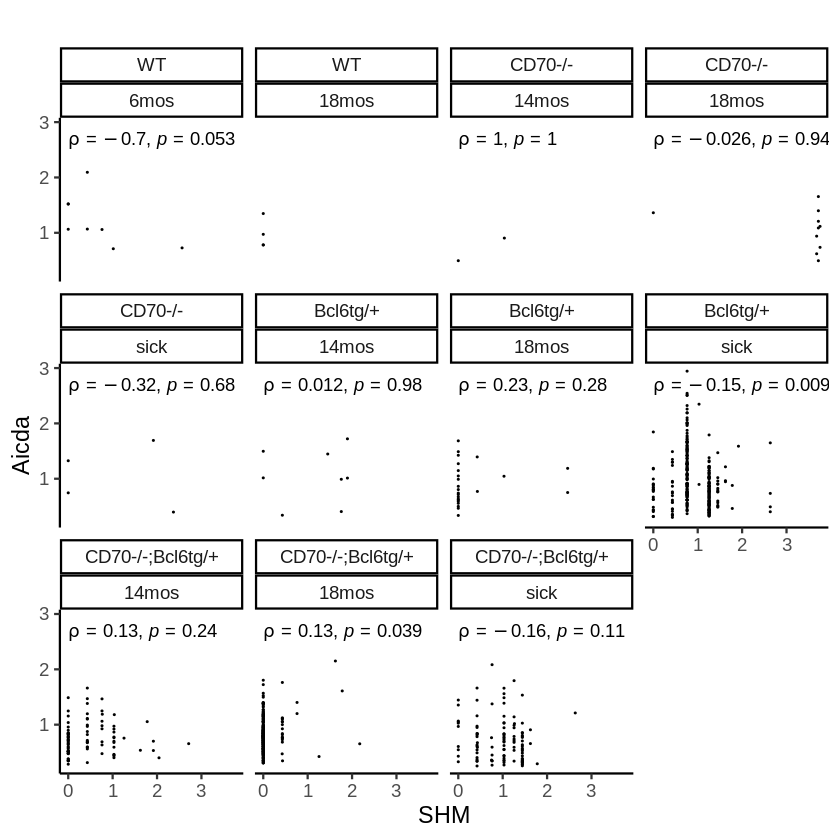

In [234]:
nonzero_df  %>% 
    ggplot(aes(x = log2(SHM+1), y = aicda)) +
    geom_point(size = 0.2) +
    labs(title="", x="SHM", y="Aicda") +
    theme_classic(base_size = 14) +
    stat_cor(method = "spearman", cor.coef.name = "rho") +
    facet_wrap(genotype~ age)

ggsave('./data/revision/correlation_aicda_shm_per_cell_by_genotype_age.pdf')

`summarise()` has grouped output by 'sampleid', 'age'. You can override using
the `.groups` argument.
Warning message:
“Computation failed in `stat_cor()`:
not enough finite observations”
Warning message:
“Computation failed in `stat_cor()`:
not enough finite observations”


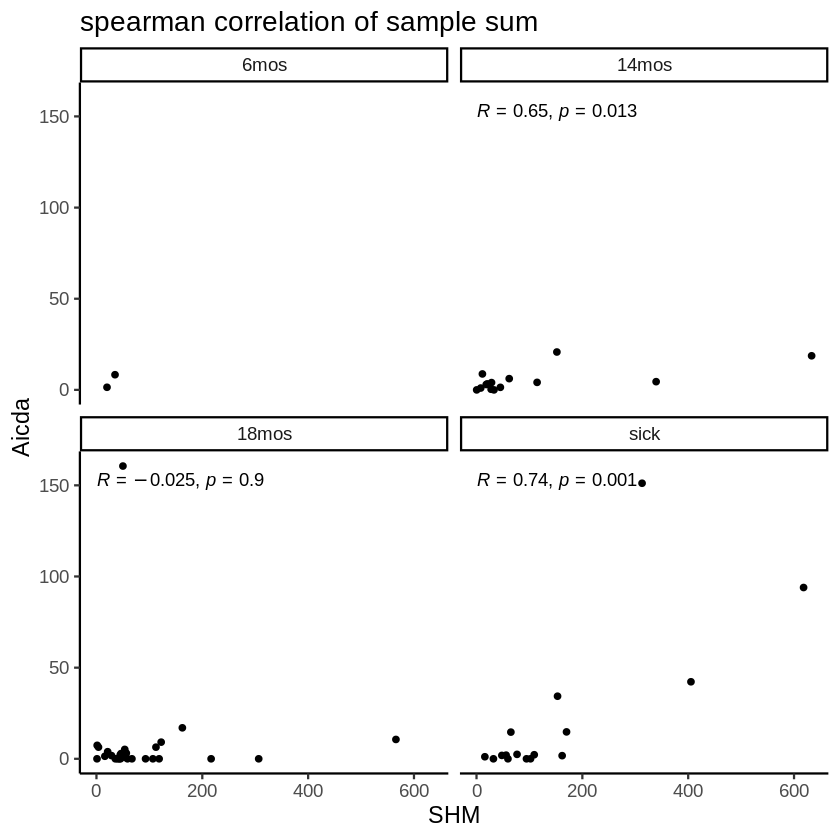

In [211]:
result <- df %>%
    group_by(sampleid, age, genotype) %>%
    summarise(across(where(is.numeric), sum, na.rm = TRUE))

result  %>% 
    ggplot(aes(x = SHM, y = aicda)) +
    geom_point(size = 1.5) +
    labs(title="", x="SHM", y="Aicda") +
    theme_classic(base_size = 14) +
    labs(title = "spearman correlation of sample sum") +
    stat_cor(method = "pearson") +
    facet_wrap(~ age)

ggsave("./data/revision/correlation_aicda_shm_sample_sum.pdf", width = 6, height = 3)

`summarise()` has grouped output by 'sampleid', 'age'. You can override using
the `.groups` argument.
Warning message:
“Computation failed in `stat_cor()`:
not enough finite observations”
Warning message:
“Computation failed in `stat_cor()`:
not enough finite observations”


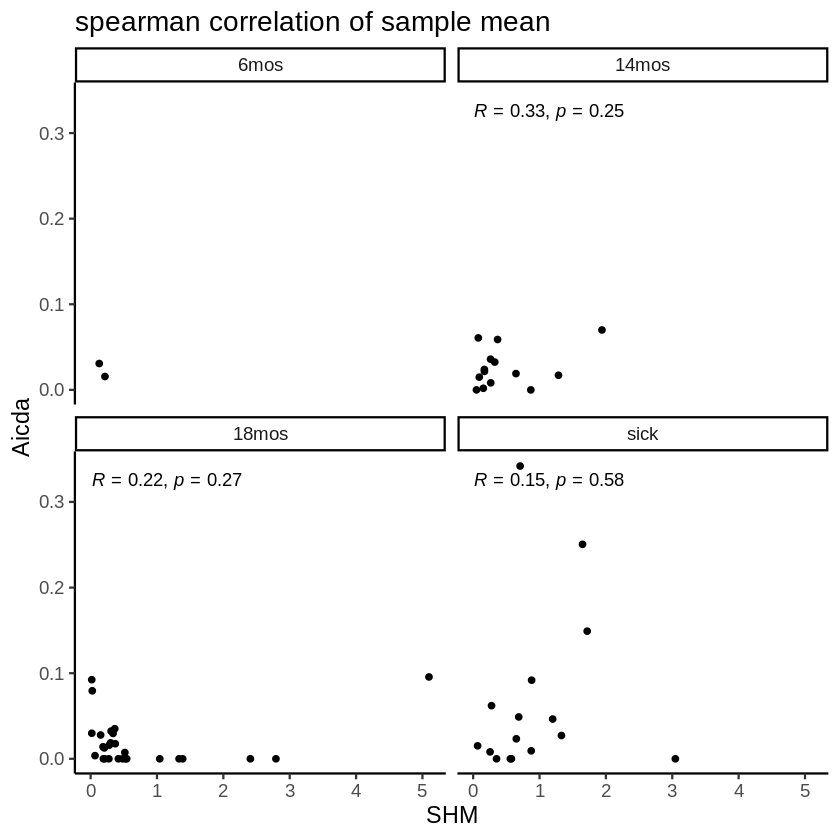

In [212]:
result <- df %>%
    group_by(sampleid, age, genotype) %>%
    summarise(across(where(is.numeric), mean, na.rm = TRUE))

result  %>% 
    ggplot(aes(x = SHM, y = aicda)) +
    geom_point(size = 1.5) +
    labs(title="", x="SHM", y="Aicda") +
    theme_classic(base_size = 14) +
    labs(title = "spearman correlation of sample mean") +
    stat_cor(method = "pearson") +
    facet_wrap(~ age)
ggsave("./data/revision/correlation_aicda_shm_sample_mean.pdf", width = 6, height = 3)

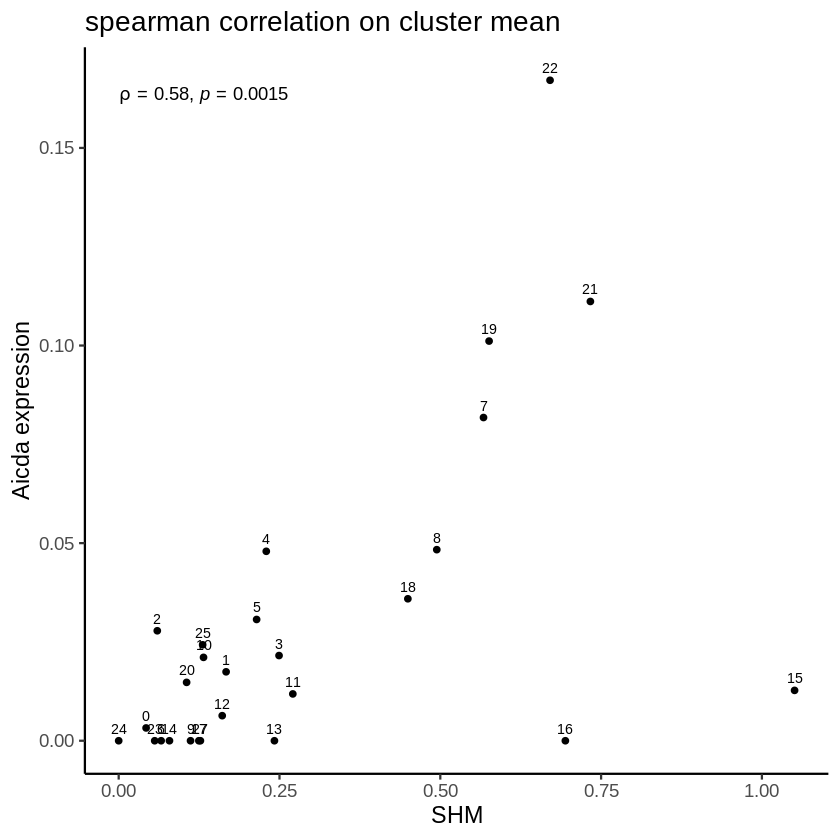

In [231]:
result <- df %>%
    group_by(seurat_clusters) %>%
    summarise(across(where(is.numeric), mean, na.rm = TRUE))

result  %>% 
    ggplot(aes(x = SHM, y = aicda)) +
    geom_point(size = 1.5) +
    labs(title="", x="SHM", y="Aicda expression") +
    theme_classic(base_size = 14) +
    labs(title = "spearman correlation on cluster mean") +
    stat_cor(method = "spearman", cor.coef.name = "rho") +
    geom_text(aes(label = seurat_clusters), vjust = -0.7, size = 3)

ggsave("./data/revision/correlation_aicda_shm_fraction_cluster_mean.pdf", width = 6, height = 4)

`summarise()` has grouped output by 'seurat_clusters'. You can override using
the `.groups` argument.


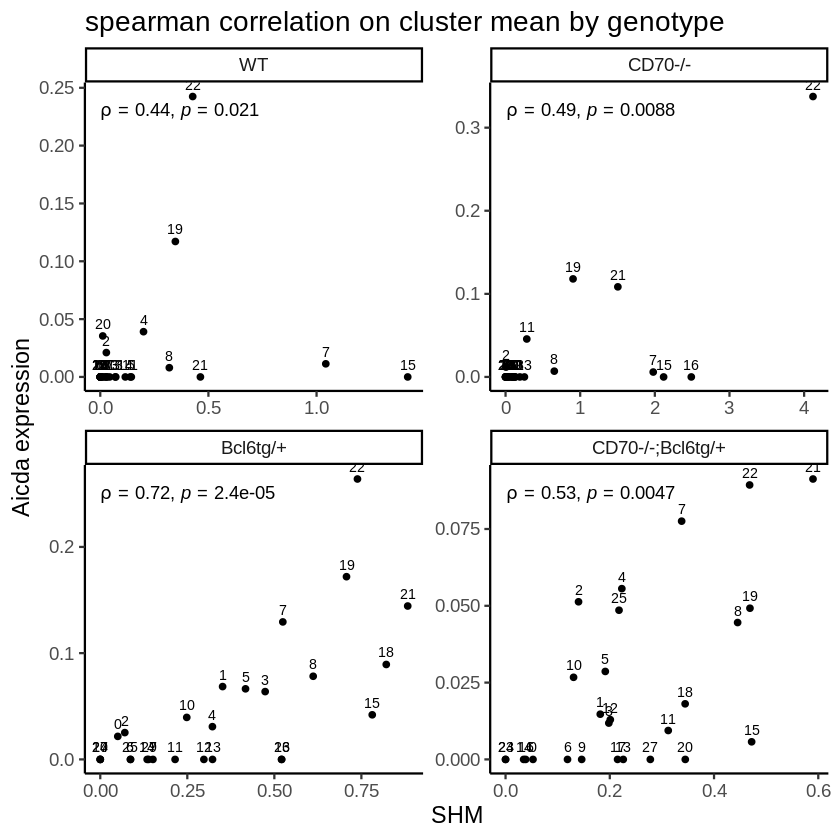

In [263]:
result <- df %>%
    group_by(seurat_clusters, genotype) %>%
    summarise(across(where(is.numeric), mean, na.rm = TRUE))

result  %>% 
    ggplot(aes(x = SHM, y = aicda)) +
    geom_point(size = 1.5) +
    labs(title="", x="SHM", y="Aicda expression") +
    theme_classic(base_size = 14) +
    labs(title = "spearman correlation on cluster mean by genotype") +
    stat_cor(method = "spearman", cor.coef.name = "rho") +
    geom_text(aes(label = seurat_clusters), vjust = -0.7, size = 3) +
    facet_wrap(~ genotype, scales = "free")
ggsave("./data/revision/correlation_aicda_shm_fraction_cluster_mean_by_genotype.pdf", width = 10, height = 8)

In [ ]:
result <- df %>%
    group_by(seurat_clusters, age) %>%
    summarise(across(where(is.numeric), mean, na.rm = TRUE))

result  %>% 
    ggplot(aes(x = SHM, y = aicda)) +
    geom_point(size = 1.5) +
    labs(title="", x="SHM", y="Aicda expression") +
    theme_classic(base_size = 14) +
    labs(title = "spearman correlation on cluster mean by age") +
    stat_cor(method = "spearman", cor.coef.name = "rho") +
    geom_text(aes(label = seurat_clusters), vjust = -0.7, size = 3) +
    facet_wrap(~ age, scales = "free")
ggsave("./data/revision/correlation_aicda_shm_fraction_cluster_mean_by_age.pdf", width = 10, height = 8)

`summarise()` has grouped output by 'seurat_clusters'. You can override using
the `.groups` argument.


In [188]:
gc_signature <- list(c("Bcl6", "Aicda", "Fas", "Cxcr4", "Cxcr5", "Mki67", "Ezh2", "Mybl1"))
post_gc_signature <- list(c("Prdm1", "Irf4", "Xbp1", "Cd38", "Sdc1"))

B_cell_cd21_cd23_low <- AddModuleScore(B_cell_cd21_cd23_low, features = gc_signature, name = "GC_score")
B_cell_cd21_cd23_low <- AddModuleScore(B_cell_cd21_cd23_low, features = post_gc_signature, name = "postGC_score")

In [51]:
B_cell_cd21_cd23_low$age  %>% table()

.
14mos 18mos  6mos  sick 
 6257 14134  4085  9596 

Warning message:
“Ignoring unknown parameters: outlier.shape, outlier.size”


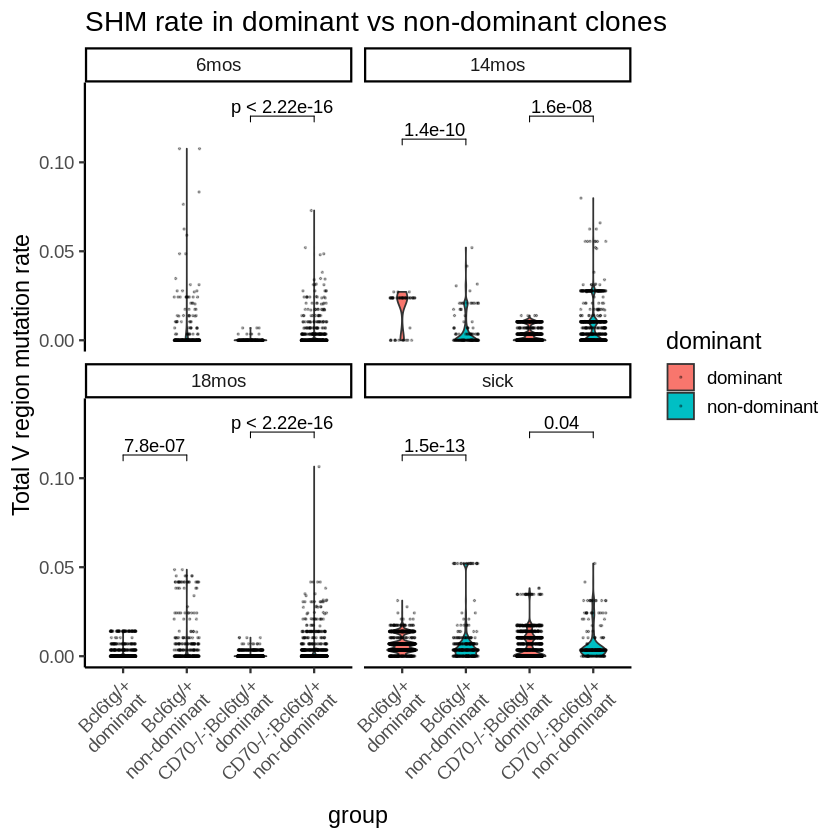

In [182]:
B_cell_cd21_cd23_low$group <- paste0(B_cell_cd21_cd23_low$genotype, "\n", B_cell_cd21_cd23_low$dominant)


df <- B_cell_cd21_cd23_low@meta.data %>%
    filter(!is.na(total_V_rate))  %>% mutate(age = factor(df$age, levels = c("6mos", "14mos", "18mos", "sick")))

ggplot(df, aes(x = group, y = total_V_rate, fill = dominant)) +
    geom_violin(width = 0.5, outlier.shape = NA, outlier.size = 0) +
    geom_jitter(width = 0.2, alpha = 0.3, size = 0.3) +
    stat_compare_means(comparisons = list(
        c("Bcl6tg/+\ndominant", "Bcl6tg/+\nnon-dominant"),
        c("CD70-/-;Bcl6tg/+\ndominant", "CD70-/-;Bcl6tg/+\nnon-dominant")
    ), method = "wilcox.test", p.adjust.method = "BH") +
    labs(title = "SHM rate in dominant vs non-dominant clones",
         y = "Total V region mutation rate") +
    theme_classic(base_size = 14) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
    facet_wrap(~ age) + scale_y_continuous(expand = expansion(mult = c(0.05, 0.15)))

ggsave("./data/revision/pseudobulk_de/deseq2/shm_v_region_rate_by_genotype_dominant.pdf", width = 6, height = 5)

Warning message:
“Computation failed in `stat_signif()`:
missing value where TRUE/FALSE needed”
Warning message:
“Computation failed in `stat_signif()`:
missing value where TRUE/FALSE needed”
Warning message:
“Computation failed in `stat_signif()`:
missing value where TRUE/FALSE needed”
Warning message:
“Computation failed in `stat_signif()`:
missing value where TRUE/FALSE needed”
Warning message:
“Computation failed in `stat_signif()`:
missing value where TRUE/FALSE needed”
Warning message:
“Computation failed in `stat_signif()`:
missing value where TRUE/FALSE needed”
Warning message:
“Computation failed in `stat_signif()`:
missing value where TRUE/FALSE needed”
Warning message:
“Computation failed in `stat_signif()`:
missing value where TRUE/FALSE needed”
Warning message:
“Computation failed in `stat_signif()`:
missing value where TRUE/FALSE needed”
Warning message:
“Computation failed in `stat_signif()`:
missing value where TRUE/FALSE needed”
Warning message:
“Computation failed in 

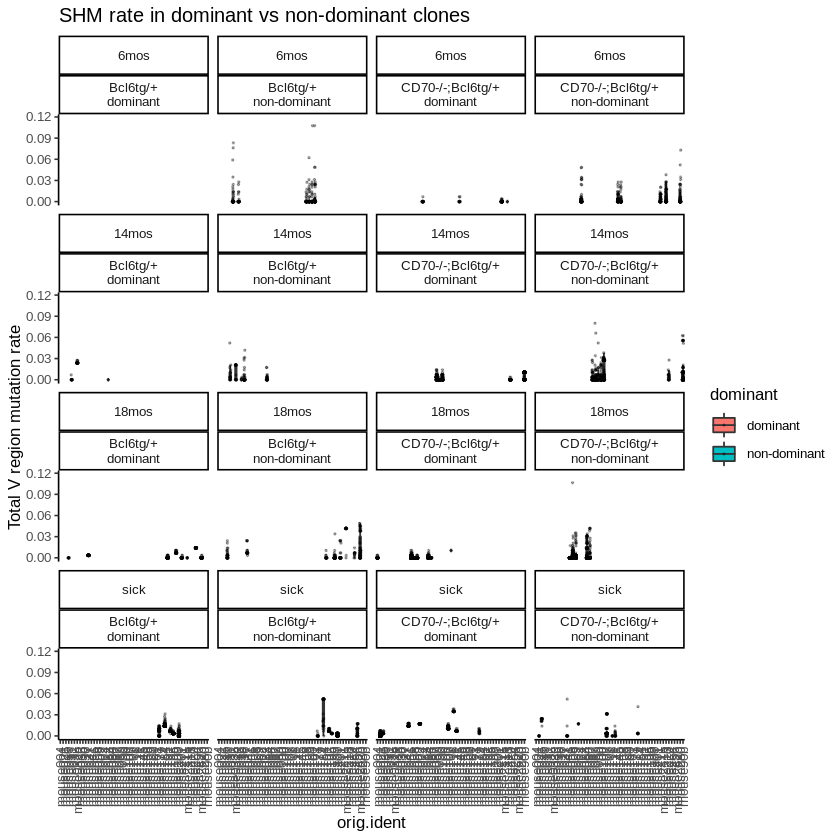

In [227]:
B_cell_cd21_cd23_low$group <- paste0(B_cell_cd21_cd23_low$genotype, "\n", B_cell_cd21_cd23_low$dominant)


df <- B_cell_cd21_cd23_low@meta.data %>%
    filter(!is.na(total_V_rate))  %>% mutate(age = factor(age, levels = c("6mos", "14mos", "18mos", "sick")))

ggplot(df, aes(x = orig.ident, y = total_V_rate, fill = dominant)) +
    geom_boxplot(width = 0.5, outlier.shape = NA, outlier.size = 0) +
    geom_jitter(width = 0.2, alpha = 0.3, size = 0.3) +
    stat_compare_means(comparisons = list(
        c("Bcl6tg/+\ndominant", "Bcl6tg/+\nnon-dominant"),
        c("CD70-/-;Bcl6tg/+\ndominant", "CD70-/-;Bcl6tg/+\nnon-dominant")
    ), method = "wilcox.test", p.adjust.method = "BH") +
    labs(title = "SHM rate in dominant vs non-dominant clones",
         y = "Total V region mutation rate") +
    theme_classic(base_size = 10) +
    theme(axis.text.x = element_text(angle = 90,hjust = 1, vjust = 0.5)) +
    facet_wrap(age~ group, drop = FALSE) + scale_y_continuous(expand = expansion(mult = c(0.05, 0.15)))

ggsave("./data/revision/pseudobulk_de/deseq2/shm_v_region_rate_by_sample.pdf", width = 20, height = 12)

Warning message:
“Ignoring unknown parameters: outlier.shape, outlier.size”


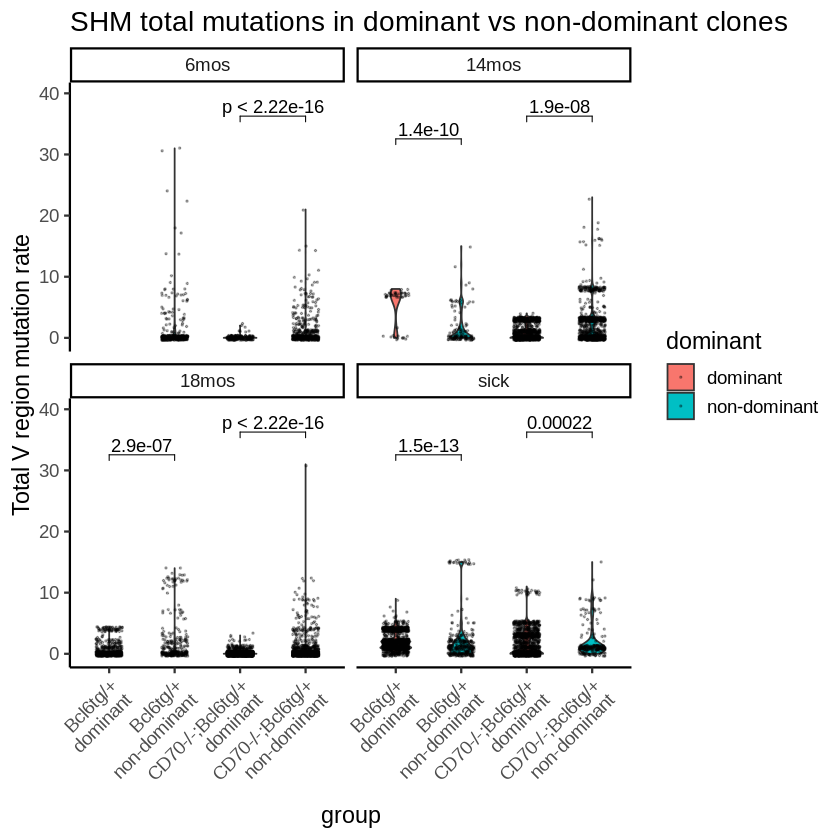

In [181]:
B_cell_cd21_cd23_low$group <- paste0(B_cell_cd21_cd23_low$genotype, "\n", B_cell_cd21_cd23_low$dominant)

df <- B_cell_cd21_cd23_low@meta.data %>%
    filter(!is.na(total_V_mutations))  %>% mutate(age = factor(df$age, levels = c("6mos", "14mos", "18mos", "sick")))

ggplot(df, aes(x = group, y = total_V_mutations, fill = dominant)) +
    geom_violin(width = 0.5, outlier.shape = NA, outlier.size = 0) +
    geom_jitter(width = 0.2, alpha = 0.3, size = 0.3) +
    stat_compare_means(comparisons = list(
        c("Bcl6tg/+\ndominant", "Bcl6tg/+\nnon-dominant"),
        c("CD70-/-;Bcl6tg/+\ndominant", "CD70-/-;Bcl6tg/+\nnon-dominant")
    ), method = "wilcox.test", p.adjust.method = "BH") +
    labs(title = "SHM total mutations in dominant vs non-dominant clones",
         y = "Total V region mutation rate") +
    theme_classic(base_size = 14) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
    facet_wrap(~ age) + scale_y_continuous(expand = expansion(mult = c(0.05, 0.15)))

ggsave("./data/revision/pseudobulk_de/deseq2/shm_v_region_total_mutation_by_genotype_dominant.pdf", width = 6, height = 5)

Warning message:
“Ignoring unknown parameters: outlier.shape, outlier.size”


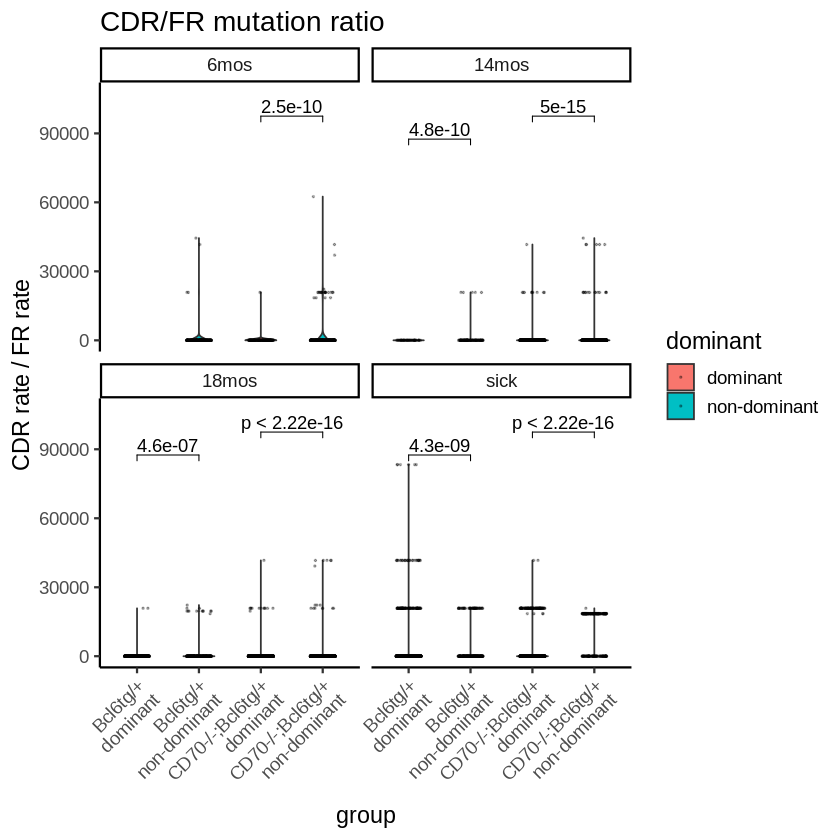

In [180]:
df$cdr_fr_ratio <- df$CDR_rate / (df$FR_rate + 1e-6)

ggplot(df, aes(x = group, y = cdr_fr_ratio, fill = dominant)) +
    geom_violin(width = 0.5, outlier.shape = NA, outlier.size = 0) +
    geom_jitter(width = 0.2, alpha = 0.3, size = 0.3) +
    stat_compare_means(comparisons = list(
        c("Bcl6tg/+\ndominant", "Bcl6tg/+\nnon-dominant"),
        c("CD70-/-;Bcl6tg/+\ndominant", "CD70-/-;Bcl6tg/+\nnon-dominant")
    ), method = "wilcox.test", p.adjust.method = "BH") +
    labs(title = "CDR/FR mutation ratio",
         y = "CDR rate / FR rate") +
    theme_classic(base_size = 14) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
    facet_wrap(~ age) + scale_y_continuous(expand = expansion(mult = c(0.05, 0.15)))

ggsave("./data/revision/pseudobulk_de/deseq2/shm_cdr_to_fr_ratio_by_genotype_dominant.pdf", width = 6, height = 5)

Warning message:
“Computation failed in `stat_signif()`:
missing value where TRUE/FALSE needed”
Warning message:
“Computation failed in `stat_signif()`:
missing value where TRUE/FALSE needed”
Warning message:
“Computation failed in `stat_signif()`:
missing value where TRUE/FALSE needed”
Warning message:
“Computation failed in `stat_signif()`:
missing value where TRUE/FALSE needed”
Warning message:
“Computation failed in `stat_signif()`:
missing value where TRUE/FALSE needed”
Warning message:
“Computation failed in `stat_signif()`:
missing value where TRUE/FALSE needed”
Warning message:
“Computation failed in `stat_signif()`:
missing value where TRUE/FALSE needed”
Warning message:
“Computation failed in `stat_signif()`:
missing value where TRUE/FALSE needed”
Warning message:
“Computation failed in `stat_signif()`:
missing value where TRUE/FALSE needed”
Warning message:
“Computation failed in `stat_signif()`:
missing value where TRUE/FALSE needed”
Warning message:
“Computation failed in 

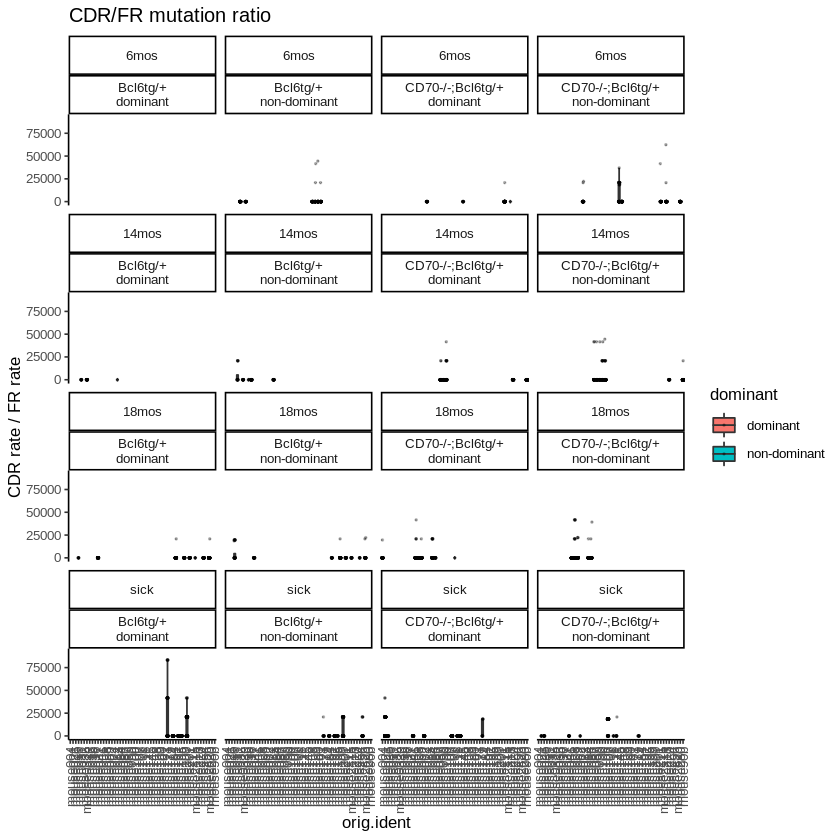

In [225]:
df$cdr_fr_ratio <- df$CDR_rate / (df$FR_rate + 1e-6)


ggplot(df, aes(x = orig.ident, y = cdr_fr_ratio, fill = dominant)) +
    geom_boxplot(width = 0.5, outlier.shape = NA, outlier.size = 0) +
    geom_jitter(width = 0.2, alpha = 0.3, size = 0.3) +
    stat_compare_means(comparisons = list(
        c("Bcl6tg/+\ndominant", "Bcl6tg/+\nnon-dominant"),
        c("CD70-/-;Bcl6tg/+\ndominant", "CD70-/-;Bcl6tg/+\nnon-dominant")
    ), method = "wilcox.test", p.adjust.method = "BH") +
    labs(title = "CDR/FR mutation ratio",
         y = "CDR rate / FR rate") +
    theme_classic(base_size = 10) +
    theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5)) +
    facet_wrap(age~ group, drop = FALSE) + scale_y_continuous(expand = expansion(mult = c(0.05, 0.15)))


ggsave("./data/revision/pseudobulk_de/deseq2/shm_cdr_to_fr_ratio_by_sample.pdf", width = 20, height = 12)

Warning message:
“Ignoring unknown parameters: outlier.shape, outlier.size”


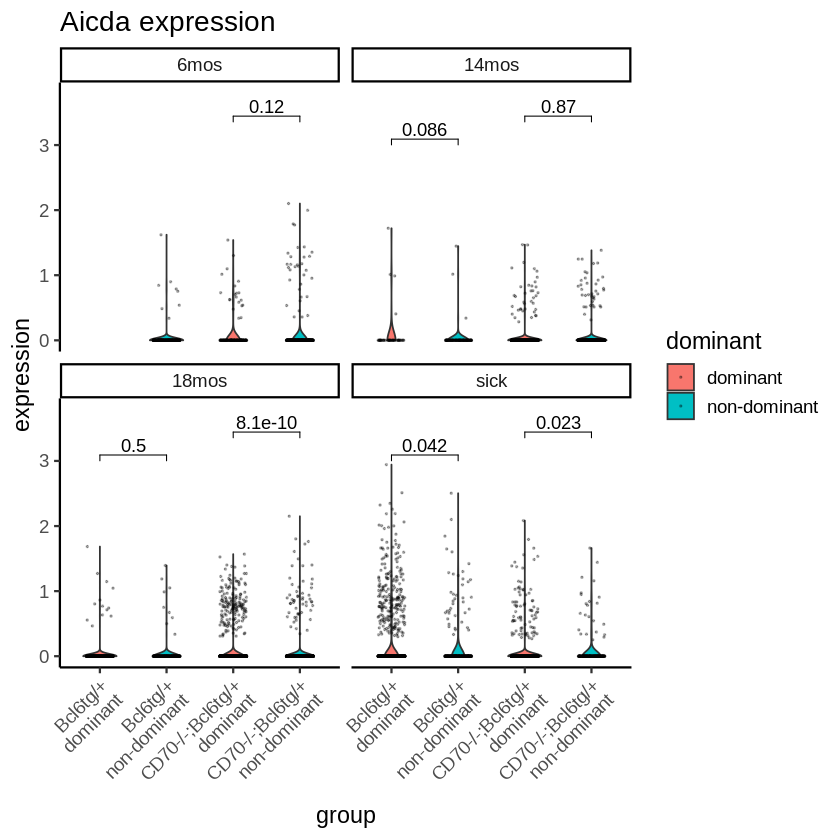

In [179]:
df$Aicda <- FetchData(B_cell_cd21_cd23_low, vars = "Aicda")[rownames(df), 1]

ggplot(df, aes(x = group, y = Aicda, fill = dominant)) +
    geom_violin(width = 0.5, outlier.shape = NA, outlier.size = 0) +
    geom_jitter(width = 0.2, alpha = 0.3, size = 0.3) +
    stat_compare_means(comparisons = list(
        c("Bcl6tg/+\ndominant", "Bcl6tg/+\nnon-dominant"),
        c("CD70-/-;Bcl6tg/+\ndominant", "CD70-/-;Bcl6tg/+\nnon-dominant")
    ), method = "wilcox.test", p.adjust.method = "BH") +
    labs(title = "Aicda expression",
         y = "expression") +
    theme_classic(base_size = 14) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
    facet_wrap(~ age) + scale_y_continuous(expand = expansion(mult = c(0.05, 0.15)))

ggsave("./data/revision/pseudobulk_de/deseq2/Aicda_expression_by_genotype_dominant.pdf", width = 6, height = 5)

Warning message:
“Computation failed in `stat_signif()`:
missing value where TRUE/FALSE needed”
Warning message:
“Computation failed in `stat_signif()`:
missing value where TRUE/FALSE needed”
Warning message:
“Computation failed in `stat_signif()`:
missing value where TRUE/FALSE needed”
Warning message:
“Computation failed in `stat_signif()`:
missing value where TRUE/FALSE needed”
Warning message:
“Computation failed in `stat_signif()`:
missing value where TRUE/FALSE needed”
Warning message:
“Computation failed in `stat_signif()`:
missing value where TRUE/FALSE needed”
Warning message:
“Computation failed in `stat_signif()`:
missing value where TRUE/FALSE needed”
Warning message:
“Computation failed in `stat_signif()`:
missing value where TRUE/FALSE needed”
Warning message:
“Computation failed in `stat_signif()`:
missing value where TRUE/FALSE needed”
Warning message:
“Computation failed in `stat_signif()`:
missing value where TRUE/FALSE needed”
Warning message:
“Computation failed in 

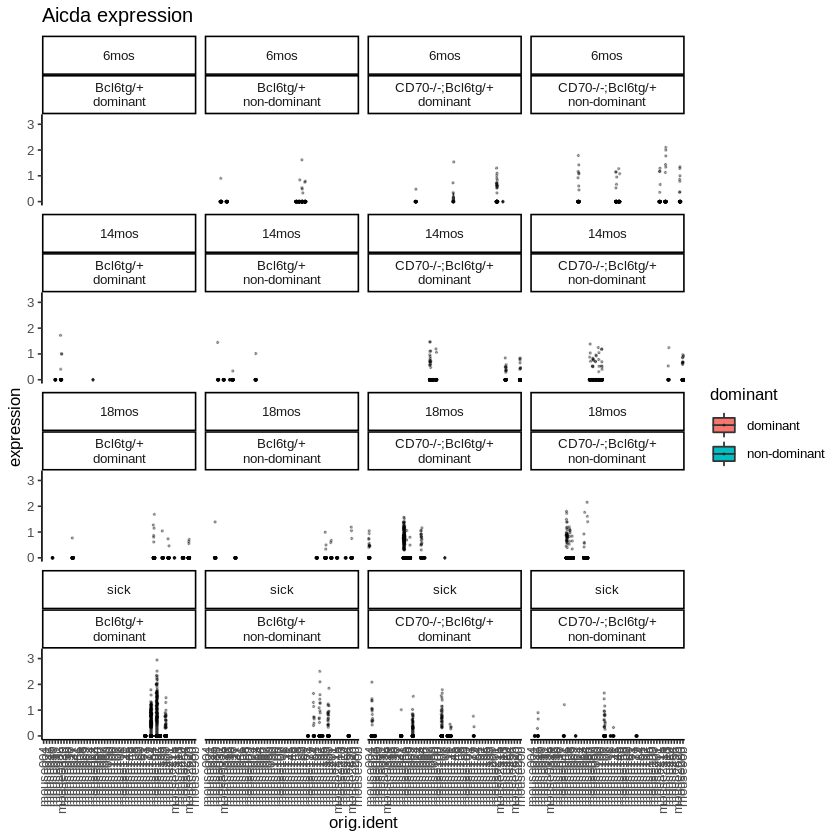

In [226]:
df$Aicda <- FetchData(B_cell_cd21_cd23_low, vars = "Aicda")[rownames(df), 1]

ggplot(df, aes(x = orig.ident, y = Aicda, fill = dominant)) +
    geom_boxplot(width = 0.5, outlier.shape = NA, outlier.size = 0) +
    geom_jitter(width = 0.2, alpha = 0.3, size = 0.3) +
    stat_compare_means(comparisons = list(
        c("Bcl6tg/+\ndominant", "Bcl6tg/+\nnon-dominant"),
        c("CD70-/-;Bcl6tg/+\ndominant", "CD70-/-;Bcl6tg/+\nnon-dominant")
    ), method = "wilcox.test", p.adjust.method = "BH") +
    labs(title = "Aicda expression",
         y = "expression") +
    theme_classic(base_size = 10) +
    theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5)) +
    facet_wrap(age~ group, drop = FALSE) + scale_y_continuous(expand = expansion(mult = c(0.05, 0.15)))


ggsave("./data/revision/pseudobulk_de/deseq2/Aicda_expression_by_sample.pdf", width = 20, height = 12)

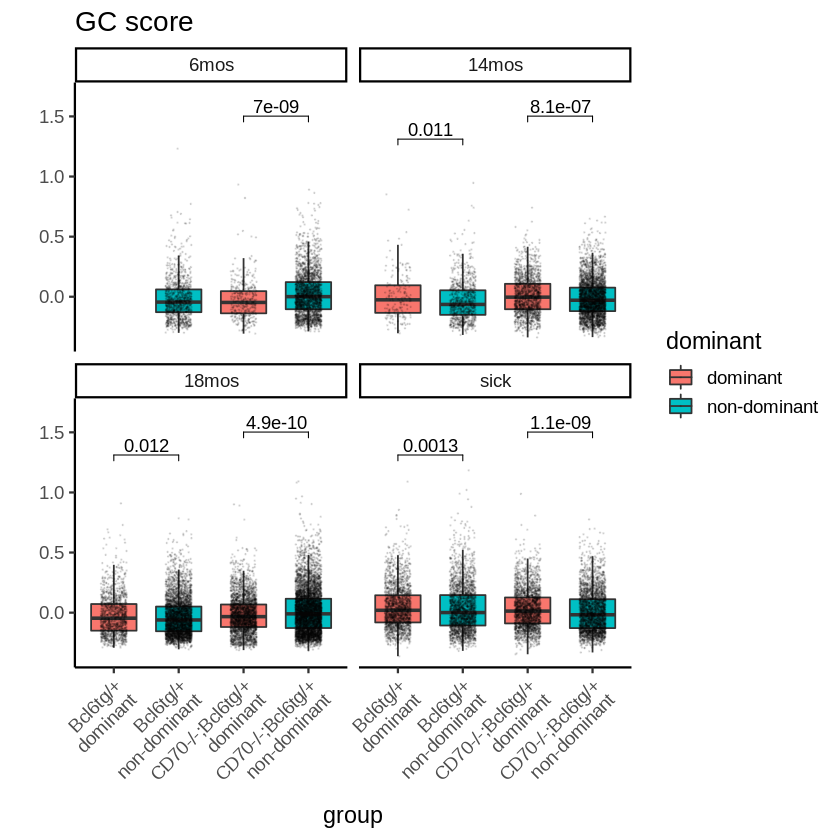

In [196]:
df <- B_cell_cd21_cd23_low@meta.data %>%
    filter(!is.na(GC_score1))  %>% 
    mutate(age = factor(age, levels = c("6mos", "14mos", "18mos", "sick")))


ggplot(df, aes(x = group, y = GC_score1, fill = dominant)) +
    geom_boxplot(width = 0.7, outlier.shape = NA, outlier.size = 0) +
    geom_jitter(width = 0.2, alpha = 0.1, size = 0.1) +
    stat_compare_means(comparisons = list(
        c("Bcl6tg/+\ndominant", "Bcl6tg/+\nnon-dominant"),
        c("CD70-/-;Bcl6tg/+\ndominant", "CD70-/-;Bcl6tg/+\nnon-dominant")
    ), method = "wilcox.test", p.adjust.method = "BH") +
    labs(title = "GC score",
         y = "") +
    theme_classic(base_size = 14) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
    facet_wrap(~ age) + scale_y_continuous(expand = expansion(mult = c(0.05, 0.15)))

ggsave("./data/revision/pseudobulk_de/deseq2/GC_by_genotype_dominant.pdf", width = 6, height = 5)

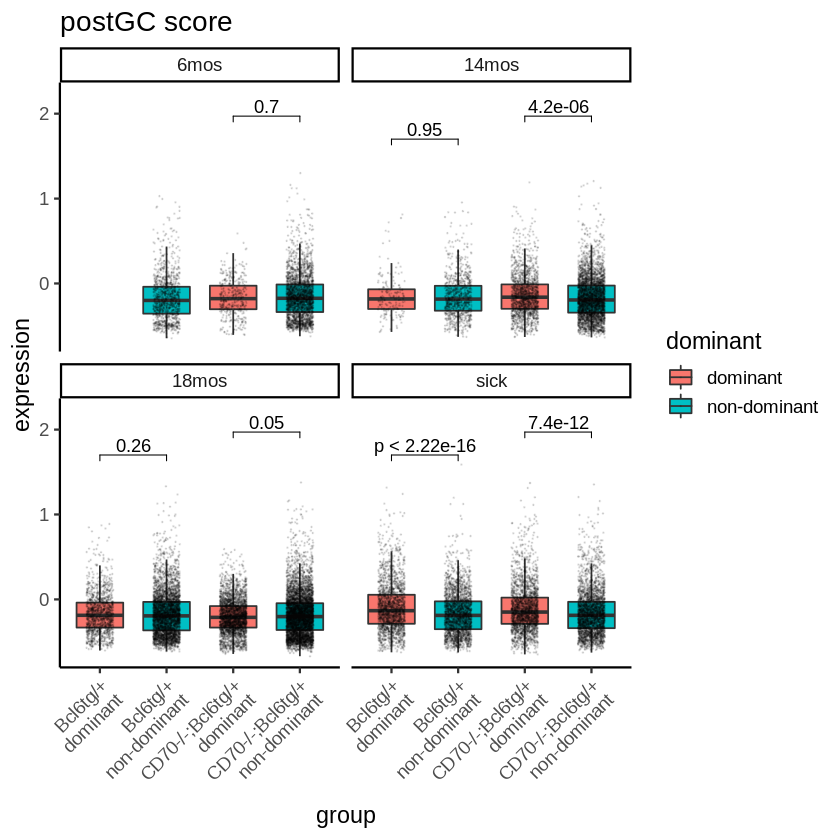

In [195]:
df <- B_cell_cd21_cd23_low@meta.data %>%
    filter(!is.na(postGC_score1))  %>% 
    mutate(age = factor(age, levels = c("6mos", "14mos", "18mos", "sick")))


ggplot(df, aes(x = group, y = postGC_score1, fill = dominant)) +
    geom_boxplot(width = 0.7, outlier.shape = NA, outlier.size = 0) +
    geom_jitter(width = 0.2, alpha = 0.1, size = 0.1) +
    stat_compare_means(comparisons = list(
        c("Bcl6tg/+\ndominant", "Bcl6tg/+\nnon-dominant"),
        c("CD70-/-;Bcl6tg/+\ndominant", "CD70-/-;Bcl6tg/+\nnon-dominant")
    ), method = "wilcox.test", p.adjust.method = "BH") +
    labs(title = "postGC score",
         y = "") +
    theme_classic(base_size = 14) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
    facet_wrap(~ age) + scale_y_continuous(expand = expansion(mult = c(0.05, 0.15)))

ggsave("./data/revision/pseudobulk_de/deseq2/postGC_by_genotype_dominant.pdf", width = 6, height = 5)